# 01 Signal Propagation

Basic 2.4 GHz wavelength, distance, path loss, and RSSI-like behavior.

This notebook stays before multipath. It models the direct TX-to-RX path only.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

C = 299_792_458
FREQ_HZ = 2.4e9
WAVELENGTH_M = C / FREQ_HZ

tx = np.array([0.6, 2.0])
rx = np.array([4.4, 2.0])

def distance(a, b):
    return np.linalg.norm(a - b, axis=-1)

def free_space_path_loss_db(distance_m, frequency_hz=FREQ_HZ):
    safe_distance = np.maximum(distance_m, 1e-6)
    return 20 * np.log10(safe_distance) + 20 * np.log10(frequency_hz) - 147.55

direct_distance_m = distance(tx, rx)
fspl_db = free_space_path_loss_db(direct_distance_m)

WAVELENGTH_M, direct_distance_m, fspl_db

(0.12491352416666666,
 np.float64(3.8000000000000003),
 np.float64(51.649896766568304))

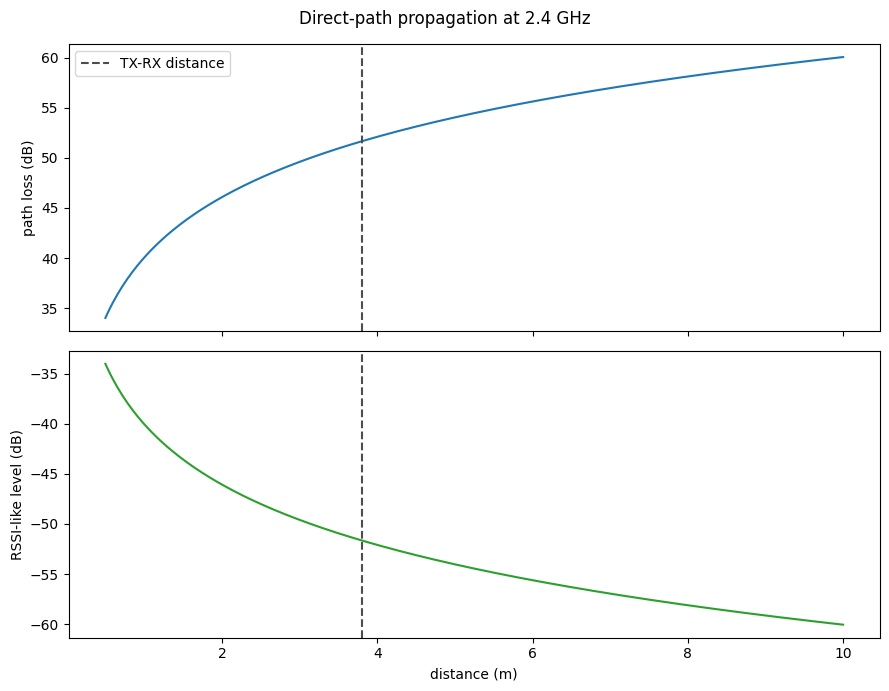

In [2]:
distances_m = np.linspace(0.5, 10.0, 300)
path_loss_db = free_space_path_loss_db(distances_m)

# RSSI-like value: assume a normalized transmit reference and subtract path loss.
rssi_like_db = -path_loss_db

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
axes[0].plot(distances_m, path_loss_db, color="tab:blue")
axes[0].axvline(direct_distance_m, color="0.3", linestyle="--", label="TX-RX distance")
axes[0].set_ylabel("path loss (dB)")
axes[0].legend()

axes[1].plot(distances_m, rssi_like_db, color="tab:green")
axes[1].axvline(direct_distance_m, color="0.3", linestyle="--")
axes[1].set_xlabel("distance (m)")
axes[1].set_ylabel("RSSI-like level (dB)")

fig.suptitle("Direct-path propagation at 2.4 GHz")
fig.tight_layout()
plt.show()

At 2.4 GHz, the wavelength is about 12.5 cm. That is why small movements can matter once reflected paths are added.